In [35]:
import os
import pandas as pd
import snowflake.connector
from dotenv import load_dotenv

load_dotenv()
conn = snowflake.connector.connect(
    user=os.getenv("SNOWFLAKE_USER"),
    password=os.getenv("SNOWFLAKE_PASSWORD"),
    account=os.getenv("SNOWFLAKE_ACCOUNT"),
    warehouse=os.getenv("SNOWFLAKE_WAREHOUSE"),
    database=os.getenv("SNOWFLAKE_DATABASE"),
    role=os.getenv("SNOWFLAKE_ROLE"),
)
df = conn.cursor().execute("select * from raw.flights").fetch_pandas_all()
df.columns = df.columns.str.lower()

In [36]:
df.head(10)

,flight_id,departure_airport_swedish,departure_airport_english,di_indicator,flight_leg_identifier__callsign,flight_leg_identifier__flight_id,flight_leg_identifier__flight_departure_date_utc,flight_leg_identifier__departure_airport_iata,flight_leg_identifier__arrival_airport_iata,flight_leg_identifier__departure_airport_icao,...,location_and_status__gate_action_swedish,location_and_status__gate_action_english,location_and_status__gate_open_utc,location_and_status__gate_close_utc,departure_time__actual_utc,departure_time__estimated_utc,baggage__estimated_first_bag_utc,direction,query_date,fetched_at
0,FR915,Rom FCO,Rome FCO,S,RYR97XH,FR915,2026-10-06 17:00:00-07:00,FCO,ARN,LIRF,...,NaN,NaN,NaT,NaT,NaT,NaT,NaT,arrivals,2026-10-07,2026-10-09 01:16:01.402031-07:00
1,FR4464,Birmingham,Birmingham,I,RYR4464,FR4464,2026-10-06 17:00:00-07:00,BHX,ARN,EGBB,...,NaN,NaN,NaT,NaT,NaT,NaT,NaT,arrivals,2026-10-07,2026-10-09 01:16:01.402031-07:00
2,FR3008,Dublin,Dublin,I,RYR3008,FR3008,2026-10-06 17:00:00-07:00,DUB,ARN,EIDW,...,NaN,NaN,NaT,NaT,NaT,NaT,NaT,arrivals,2026-10-07,2026-10-09 01:16:01.402031-07:00
3,FR7619,Palma,Palma,S,RYR9JP,FR7619,2026-10-06 17:00:00-07:00,PMI,ARN,LEPA,...,NaN,NaN,NaT,NaT,NaT,NaT,NaT,arrivals,2026-10-07,2026-10-09 01:16:01.402031-07:00
4,FR7694,Chania,Chania,S,RYR7694,FR7694,2026-10-06 17:00:00-07:00,CHQ,ARN,LGSA,...,NaN,NaN,NaT,NaT,NaT,NaT,NaT,arrivals,2026-10-07,2026-10-09 01:16:01.402031-07:00
5,FR9447,Manchester,Manchester,I,RYR9447,FR9447,2026-10-06 17:00:00-07:00,MAN,ARN,EGCC,...,NaN,NaN,NaT,NaT,NaT,NaT,NaT,arrivals,2026-10-07,2026-10-09 01:16:01.402031-07:00
6,DE4409,Frankfurt,Frankfurt,S,CFG4409,DE4409,2026-10-06 17:00:00-07:00,FRA,ARN,EDDF,...,NaN,NaN,NaT,NaT,NaT,NaT,NaT,arrivals,2026-10-07,2026-10-09 01:16:01.402031-07:00
7,DE4405,Frankfurt,Frankfurt,S,CFG4405,DE4405,2026-10-06 17:00:00-07:00,FRA,ARN,EDDF,...,NaN,NaN,NaT,NaT,NaT,NaT,NaT,arrivals,2026-10-07,2026-10-09 01:16:01.402031-07:00
8,DE4403,Frankfurt,Frankfurt,S,CFG4403,DE4403,2026-10-06 17:00:00-07:00,FRA,ARN,EDDF,...,NaN,NaN,NaT,NaT,NaT,NaT,NaT,arrivals,2026-10-07,2026-10-09 01:16:01.402031-07:00
9,W62407,Budapest,Budapest,S,WZZ2407,W62407,2026-10-06 17:00:00-07:00,BUD,ARN,LHBP,...,NaN,NaN,NaT,NaT,NaT,NaT,NaT,arrivals,2026-10-07,2026-10-09 01:16:01.402031-07:00


In [37]:
df.shape

(2121, 48)

In [38]:
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 48 columns):
 #   Column                                            Non-Null Count  Dtype                              
---  ------                                            --------------  -----                              
 0   flight_id                                         2121 non-null   str                                
 1   departure_airport_swedish                         1063 non-null   str                                
 2   departure_airport_english                         1063 non-null   str                                
 3   di_indicator                                      2121 non-null   str                                
 4   flight_leg_identifier__callsign                   2121 non-null   str                                
 5   flight_leg_identifier__flight_id                  2121 non-null   str                                
 6   flight_leg_identifier__flight_departure_dat

In [39]:
df.columns

Index(['flight_id', 'departure_airport_swedish', 'departure_airport_english',
       'di_indicator', 'flight_leg_identifier__callsign',
       'flight_leg_identifier__flight_id',
       'flight_leg_identifier__flight_departure_date_utc',
       'flight_leg_identifier__departure_airport_iata',
       'flight_leg_identifier__arrival_airport_iata',
       'flight_leg_identifier__departure_airport_icao',
       'flight_leg_identifier__arrival_airport_icao',
       'location_and_status__terminal',
       'location_and_status__flight_leg_status',
       'location_and_status__flight_leg_status_swedish',
       'location_and_status__flight_leg_status_english',
       'arrival_time__scheduled_utc', 'airline_operator__iata',
       'airline_operator__icao', 'airline_operator__name', '_dlt_load_id',
       '_dlt_id', 'baggage__baggage_claim_unit',
       'flight_leg_identifier__aircraft_registration',
       'flight_leg_identifier__ssr_code', 'arrival_time__estimated_utc',
       'baggage__first_

In [40]:
df.isna().sum()    

flight_id                                              0
departure_airport_swedish                           1058
departure_airport_english                           1058
di_indicator                                           0
flight_leg_identifier__callsign                        0
flight_leg_identifier__flight_id                       0
flight_leg_identifier__flight_departure_date_utc       0
flight_leg_identifier__departure_airport_iata          0
flight_leg_identifier__arrival_airport_iata            0
flight_leg_identifier__departure_airport_icao          0
flight_leg_identifier__arrival_airport_icao            0
location_and_status__terminal                          0
location_and_status__flight_leg_status                 0
location_and_status__flight_leg_status_swedish         0
location_and_status__flight_leg_status_english         0
arrival_time__scheduled_utc                         1058
airline_operator__iata                                 0
airline_operator__icao         

In [41]:
df.fillna("missing") 

,flight_id,departure_airport_swedish,departure_airport_english,di_indicator,flight_leg_identifier__callsign,flight_leg_identifier__flight_id,flight_leg_identifier__flight_departure_date_utc,flight_leg_identifier__departure_airport_iata,flight_leg_identifier__arrival_airport_iata,flight_leg_identifier__departure_airport_icao,...,location_and_status__gate_action_swedish,location_and_status__gate_action_english,location_and_status__gate_open_utc,location_and_status__gate_close_utc,departure_time__actual_utc,departure_time__estimated_utc,baggage__estimated_first_bag_utc,direction,query_date,fetched_at
0,FR915,Rom FCO,Rome FCO,S,RYR97XH,FR915,2026-10-06 17:00:00-07:00,FCO,ARN,LIRF,...,missing,missing,missing,missing,missing,missing,missing,arrivals,2026-10-07,2026-10-09 01:16:01.402031-07:00
1,FR4464,Birmingham,Birmingham,I,RYR4464,FR4464,2026-10-06 17:00:00-07:00,BHX,ARN,EGBB,...,missing,missing,missing,missing,missing,missing,missing,arrivals,2026-10-07,2026-10-09 01:16:01.402031-07:00
2,FR3008,Dublin,Dublin,I,RYR3008,FR3008,2026-10-06 17:00:00-07:00,DUB,ARN,EIDW,...,missing,missing,missing,missing,missing,missing,missing,arrivals,2026-10-07,2026-10-09 01:16:01.402031-07:00
3,FR7619,Palma,Palma,S,RYR9JP,FR7619,2026-10-06 17:00:00-07:00,PMI,ARN,LEPA,...,missing,missing,missing,missing,missing,missing,missing,arrivals,2026-10-07,2026-10-09 01:16:01.402031-07:00
4,FR7694,Chania,Chania,S,RYR7694,FR7694,2026-10-06 17:00:00-07:00,CHQ,ARN,LGSA,...,missing,missing,missing,missing,missing,missing,missing,arrivals,2026-10-07,2026-10-09 01:16:01.402031-07:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2116,SK1136,missing,missing,D,SAS1136,SK1136,2026-10-07 17:00:00-07:00,RNB,ARN,ESDF,...,missing,missing,missing,missing,missing,missing,missing,departures,2026-10-08,2026-10-09 01:16:01.402031-07:00
2117,SK1126,missing,missing,D,SAS1126,SK1126,2026-10-07 17:00:00-07:00,RNB,ARN,ESDF,...,Utgång stängd,Gate closed,2026-10-07 20:22:20-07:00,2026-10-07 20:38:51-07:00,2026-10-07 20:45:00-07:00,missing,missing,departures,2026-10-08,2026-10-09 01:16:01.402031-07:00
2118,SK1130,missing,missing,D,SAS1130,SK1130,2026-10-07 17:00:00-07:00,RNB,ARN,ESDF,...,Utgång stängd,Gate closed,2026-10-08 06:26:47-07:00,2026-10-08 06:46:22-07:00,2026-10-08 06:54:00-07:00,missing,missing,departures,2026-10-08,2026-10-09 01:16:01.402031-07:00
2119,SK1138,missing,missing,D,SAS1138,SK1138,2026-10-07 17:00:00-07:00,RNB,ARN,ESDF,...,Utgång stängd,Gate closed,2026-10-08 09:01:28-07:00,2026-10-08 09:19:50-07:00,2026-10-08 09:25:00-07:00,missing,missing,departures,2026-10-08,2026-10-09 01:16:01.402031-07:00


In [42]:
df.duplicated().sum()

np.int64(0)

In [43]:
arr = df[df["direction"] == "arrivals"].dropna(axis=1, how="all").copy()
dep = df[df["direction"] == "departures"].dropna(axis=1, how="all").copy()

print(arr.shape, dep.shape)   # ska bli (1063, ...) och (1058, ...)
assert len(arr) == 1063 and len(dep) == 1058

(1063, 33) (1058, 39)


In [44]:
# Kortare kolumnnamn för de viktigaste fälten
arr = arr.copy().rename(columns={
    "arrival_time__scheduled_utc": "scheduled",
    "arrival_time__estimated_utc": "estimated",
    "arrival_time__actual_utc": "actual",
    "location_and_status__flight_leg_status_english": "status_raw",
    "airline_operator__name": "airline",
    "departure_airport_english": "other_airport",
    "location_and_status__gate": "gate",
    "location_and_status__terminal ": "terminal",
})
dep = dep.copy().rename(columns={
    "departure_time__scheduled_utc": "scheduled",
    "departure_time__estimated_utc": "estimated",
    "departure_time__actual_utc": "actual",
    "location_and_status__flight_leg_status_english": "status_raw",
    "airline_operator__name": "airline",
    "arrival_airport_english": "other_airport",
    "location_and_status__gate": "gate",
    "location_and_status__terminal ": "terminal",
})

# Statusen innehåller klockslag ("Landed 09:23") - ta bara första ordet
for d in (arr, dep):
    d["status"] = d["status_raw"].str.split(" ").str[0]

print("arrivals:", arr.shape, "| departures:", dep.shape)
arr.head(3)
dep.head(3)

arrivals: (1063, 34) | departures: (1058, 40)


,flight_id,di_indicator,flight_leg_identifier__callsign,flight_leg_identifier__flight_id,flight_leg_identifier__flight_departure_date_utc,flight_leg_identifier__departure_airport_iata,flight_leg_identifier__arrival_airport_iata,flight_leg_identifier__departure_airport_icao,flight_leg_identifier__arrival_airport_icao,location_and_status__terminal,...,location_and_status__gate_action_swedish,location_and_status__gate_action_english,location_and_status__gate_open_utc,location_and_status__gate_close_utc,actual,estimated,direction,query_date,fetched_at,status
349,FR7693,S,RYR8PB,FR7693,2026-10-06 17:00:00-07:00,ARN,CHQ,ESSA,LGSA,T5,...,NaN,NaN,NaT,NaT,NaT,NaT,departures,2026-10-07,2026-10-09 01:16:01.402031-07:00,Deleted
350,FR914,S,RYR4HD,FR914,2026-10-06 17:00:00-07:00,ARN,FCO,ESSA,LIRF,T5,...,NaN,NaN,NaT,NaT,NaT,NaT,departures,2026-10-07,2026-10-09 01:16:01.402031-07:00,Deleted
351,FR4465,I,RYR4465,FR4465,2026-10-06 17:00:00-07:00,ARN,BHX,ESSA,EGBB,T5,...,NaN,NaN,NaT,NaT,NaT,NaT,departures,2026-10-07,2026-10-09 01:16:01.402031-07:00,Deleted


In [45]:
for namn, d in [("arrivals", arr), ("departures", dep)]:
    print(f"{namn}: {len(d)} rader, {d['flight_id'].nunique()} unika flight_id, "
          f"{d['scheduled'].min()} -> {d['scheduled'].max()}")

# Hur många gånger förekommer varje flight_id?
dep["flight_id"].value_counts().describe()

arrivals: 1063 rader, 619 unika flight_id, 2026-10-06 15:00:00-07:00 -> 2026-10-08 14:55:00-07:00
departures: 1058 rader, 620 unika flight_id, 2026-10-06 20:45:00-07:00 -> 2026-10-08 14:40:00-07:00


count    620.000000
mean       1.706452
std        0.455755
min        1.000000
25%        1.000000
50%        2.000000
75%        2.000000
max        2.000000
Name: count, dtype: float64

In [46]:
# Exempel på ett flyg som finns flera gånger
exempel = dep["flight_id"].value_counts().index[0]
dep[dep["flight_id"] == exempel].sort_values("_dlt_load_id")[
    ["flight_id", "scheduled", "estimated", "actual", "status_raw", "gate", "_dlt_load_id"]
]

,flight_id,scheduled,estimated,actual,status_raw,gate,_dlt_load_id
351,FR4465,2026-10-07 02:10:00-07:00,NaT,NaT,Deleted,NaN,1791533761.399877
1406,FR4465,2026-10-08 02:10:00-07:00,NaT,NaT,Deleted,NaN,1791533761.399877


In [47]:
cols = ["scheduled", "estimated", "actual", "status", "airline", "gate"]
pd.DataFrame({
    "arrivals_%": arr[cols].isna().mean().mul(100).round(1),
    "departures_%": dep[cols].isna().mean().mul(100).round(1),
})

,arrivals_%,departures_%
scheduled,0.0,0.0
estimated,17.6,91.6
actual,18.0,18.3
status,0.0,0.0
airline,0.0,0.0
gate,24.6,17.6


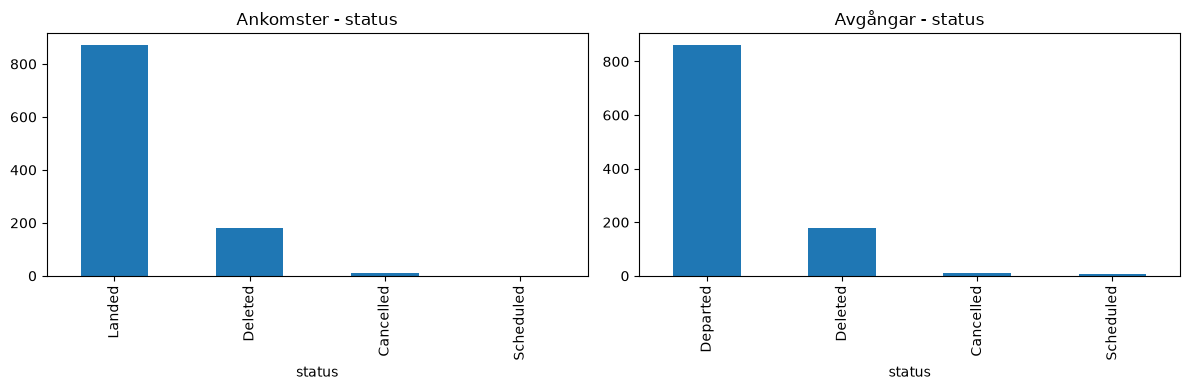

In [48]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
arr["status"].value_counts().plot.bar(ax=axes[0], title="Ankomster - status")
dep["status"].value_counts().plot.bar(ax=axes[1], title="Avgångar - status")
plt.tight_layout(); plt.show()

In [49]:
for d in (arr, dep):
    d["delay_min"] = (d["actual"] - d["scheduled"]).dt.total_seconds() / 60

print("Ankomster:"); print(arr["delay_min"].describe().round(1))
print("\nAvgångar:"); print(dep["delay_min"].describe().round(1))

Ankomster:
count    872.0
mean      -3.5
std       24.3
min      -46.0
25%      -14.9
50%       -7.8
75%        2.0
max      404.1
Name: delay_min, dtype: float64

Avgångar:
count    864.0
mean       3.8
std       17.4
min      -19.0
25%       -5.1
50%       -0.2
75%        7.1
max      184.0
Name: delay_min, dtype: float64


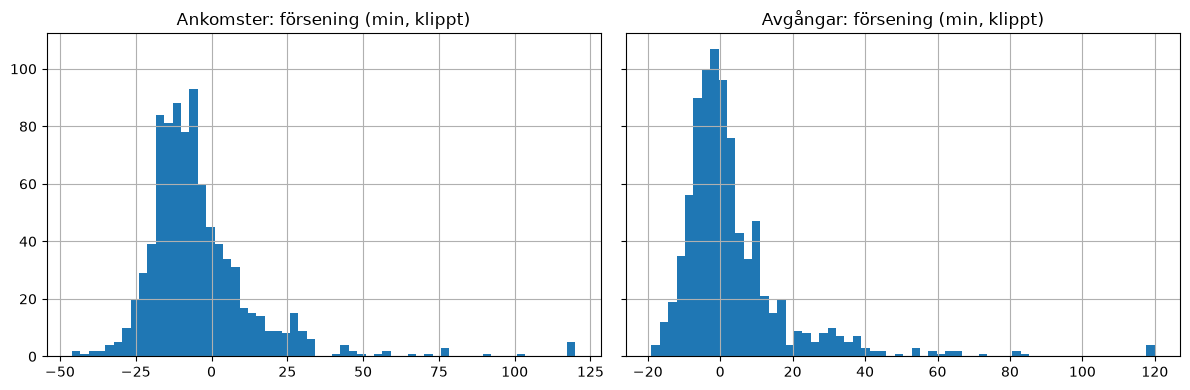

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
arr["delay_min"].clip(-60, 120).hist(bins=60, ax=axes[0]); axes[0].set_title("Ankomster: försening (min, klippt)")
dep["delay_min"].clip(-60, 120).hist(bins=60, ax=axes[1]); axes[1].set_title("Avgångar: försening (min, klippt)")
plt.tight_layout(); plt.show()

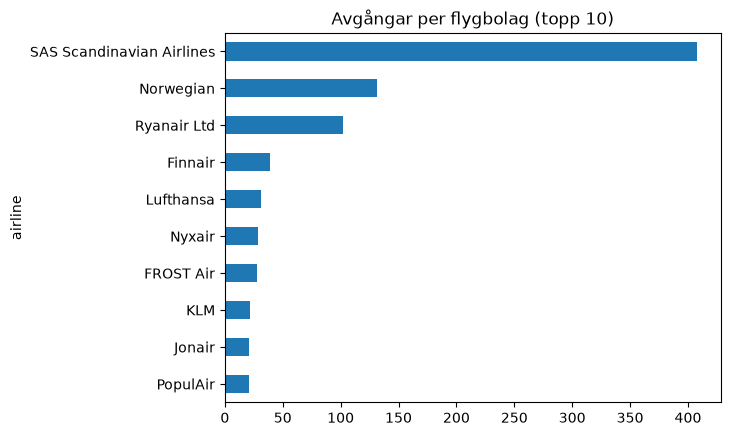

In [51]:
topp = dep["airline"].value_counts().head(10)
topp.sort_values().plot.barh(title="Avgångar per flygbolag (topp 10)")
plt.show()

In [52]:
(dep.dropna(subset=["delay_min"])
      .groupby("airline")["delay_min"]
      .agg(["count", "mean", "median"])
      .query("count >= 30")
      .sort_values("mean", ascending=False)
      .round(1))

,count,mean,median
airline,,,
Ryanair Ltd,79,10.7,-0.1
Norwegian,125,7.8,0.3
SAS Scandinavian Airlines,344,1.0,-0.7
Finnair,37,-2.6,-3.8


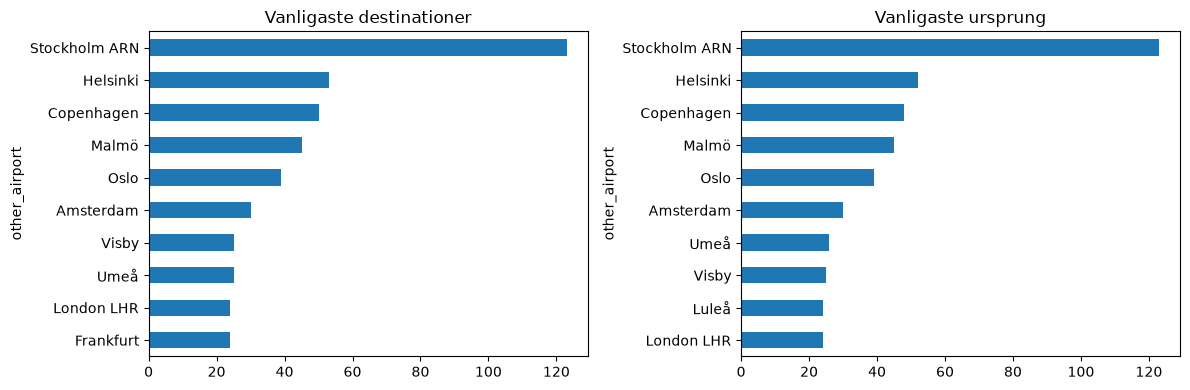

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
dep["other_airport"].value_counts().head(10).sort_values().plot.barh(ax=axes[0], title="Vanligaste destinationer")
arr["other_airport"].value_counts().head(10).sort_values().plot.barh(ax=axes[1], title="Vanligaste ursprung")
plt.tight_layout(); plt.show()

In [58]:
dep["flight_leg_identifier__departure_airport_iata"].value_counts()

flight_leg_identifier__departure_airport_iata
ARN    700
GOT    155
MMX     45
BMA     45
UME     30
LLA     29
VBY     25
OSD     13
RNB     12
KRN      4
Name: count, dtype: int64